In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/telco_cleaned.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7032, 24)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_30,churn_60,churn_90
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,0,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,0,0,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1,0,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0,0,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,0,0


## 1. Overall Churn Distribution
Baseline churn rate across all 7,032 customers.

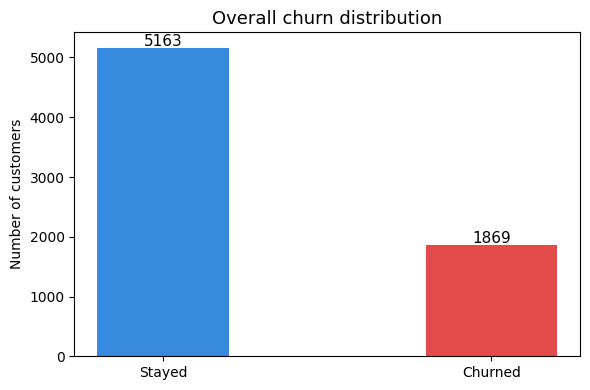

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = ['#378ADD', '#E24B4A']
counts = df['Churn'].value_counts()
bars = ax.bar(['Stayed', 'Churned'], counts.values, color=colors, width=0.4)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', fontsize=11)

ax.set_title('Overall churn distribution', fontsize=13)
ax.set_ylabel('Number of customers')
plt.tight_layout()
plt.savefig('../data/churn_distribution.png', dpi=150)
plt.show()

2. Churn by Contract Type
Contract type is the strongest predictor of churn behavior.

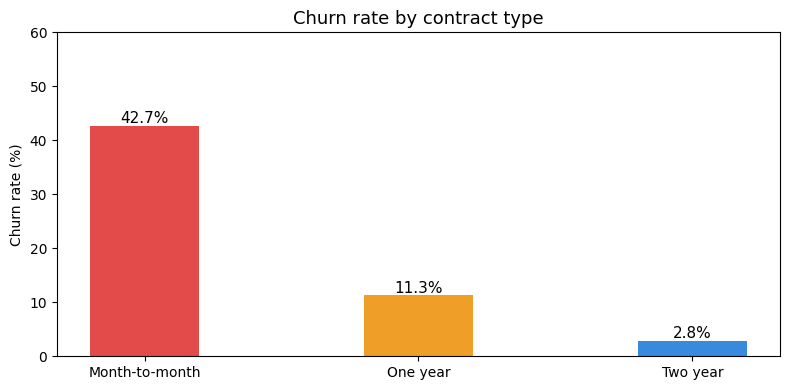

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
bars = ax.bar(contract_churn.index, contract_churn.values * 100,
              color=['#E24B4A', '#EF9F27', '#378ADD'], width=0.4)

for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1%}', ha='center', fontsize=11)

ax.set_title('Churn rate by contract type', fontsize=13)
ax.set_ylabel('Churn rate (%)')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig('../data/churn_by_contract.png', dpi=150)
plt.show()

3. Tenure Distribution
Churned customers are heavily concentrated in early months — 
validating our 3-window approach based on tenure.

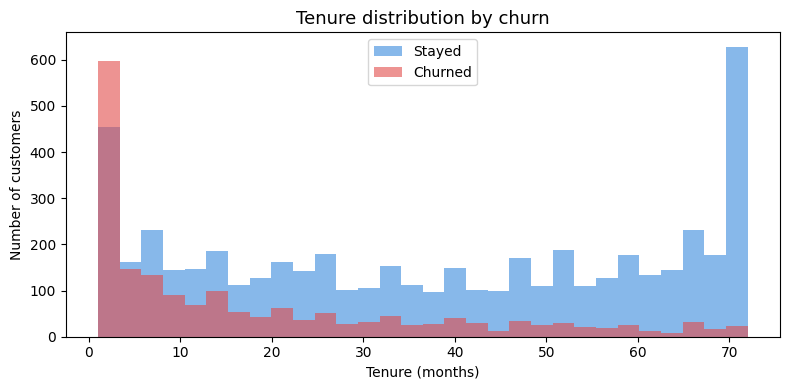

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.6,
        color='#378ADD', label='Stayed')
ax.hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.6,
        color='#E24B4A', label='Churned')

ax.set_title('Tenure distribution by churn', fontsize=13)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of customers')
ax.legend()
plt.tight_layout()
plt.savefig('../data/tenure_distribution.png', dpi=150)
plt.show()

4. Monthly Charges by Churn Status

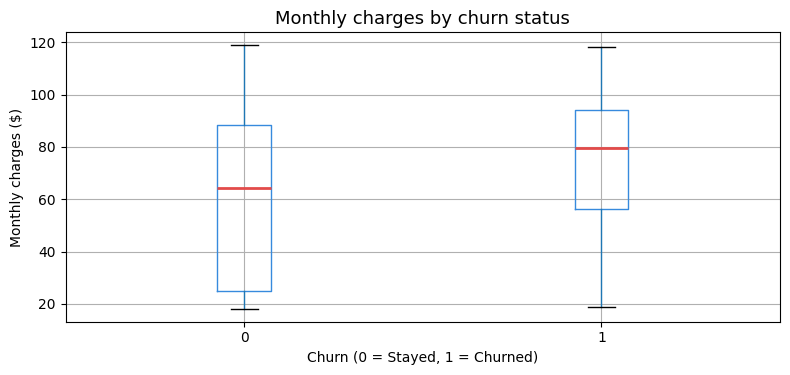

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

df.boxplot(column='MonthlyCharges', by='Churn', ax=ax,
           boxprops=dict(color='#378ADD'),
           medianprops=dict(color='#E24B4A', linewidth=2))

ax.set_title('Monthly charges by churn status', fontsize=13)
ax.set_xlabel('Churn (0 = Stayed, 1 = Churned)')
ax.set_ylabel('Monthly charges ($)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../data/monthly_charges_boxplot.png', dpi=150)
plt.show()

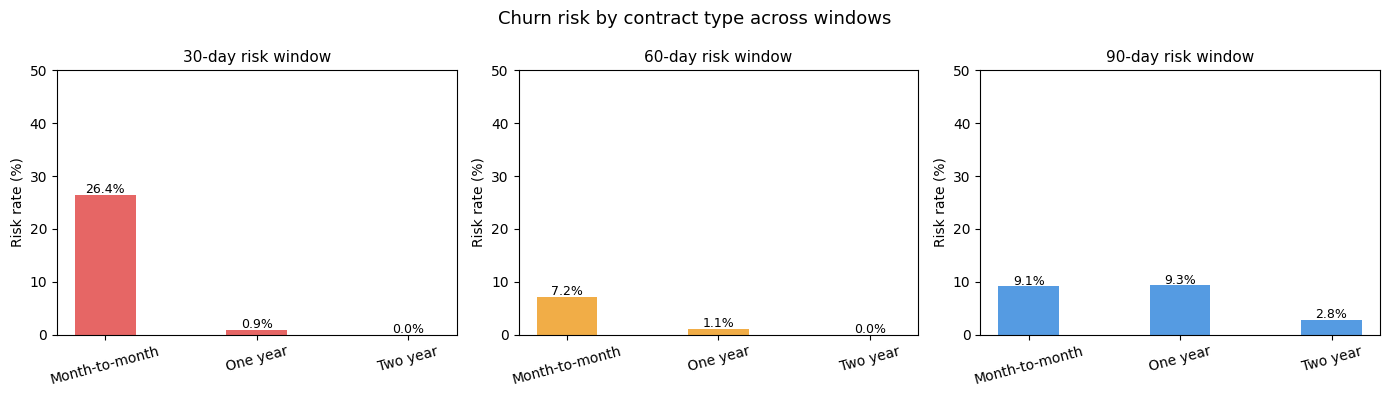

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

windows = ['churn_30', 'churn_60', 'churn_90']
titles = ['30-day risk window', '60-day risk window', '90-day risk window']
colors = ['#E24B4A', '#EF9F27', '#378ADD']

for ax, window, title, color in zip(axes, windows, titles, colors):
    data = df.groupby('Contract')[window].mean() * 100
    bars = ax.bar(data.index, data.values, color=color, width=0.4, alpha=0.85)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Risk rate (%)')
    ax.set_ylim(0, 50)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Churn risk by contract type across windows', fontsize=13)
plt.tight_layout()
plt.savefig('../data/windows_by_contract.png', dpi=150)
plt.show()